# The  the reason to use the Ridge regresssion

- The if the model is overfitted as the traning of the model completely depends on the trainig data so there may be bias into the model 
- so to deal with it we add some bias into the model due to which the prediction duringt the training is reduced but during the test it perfroms well

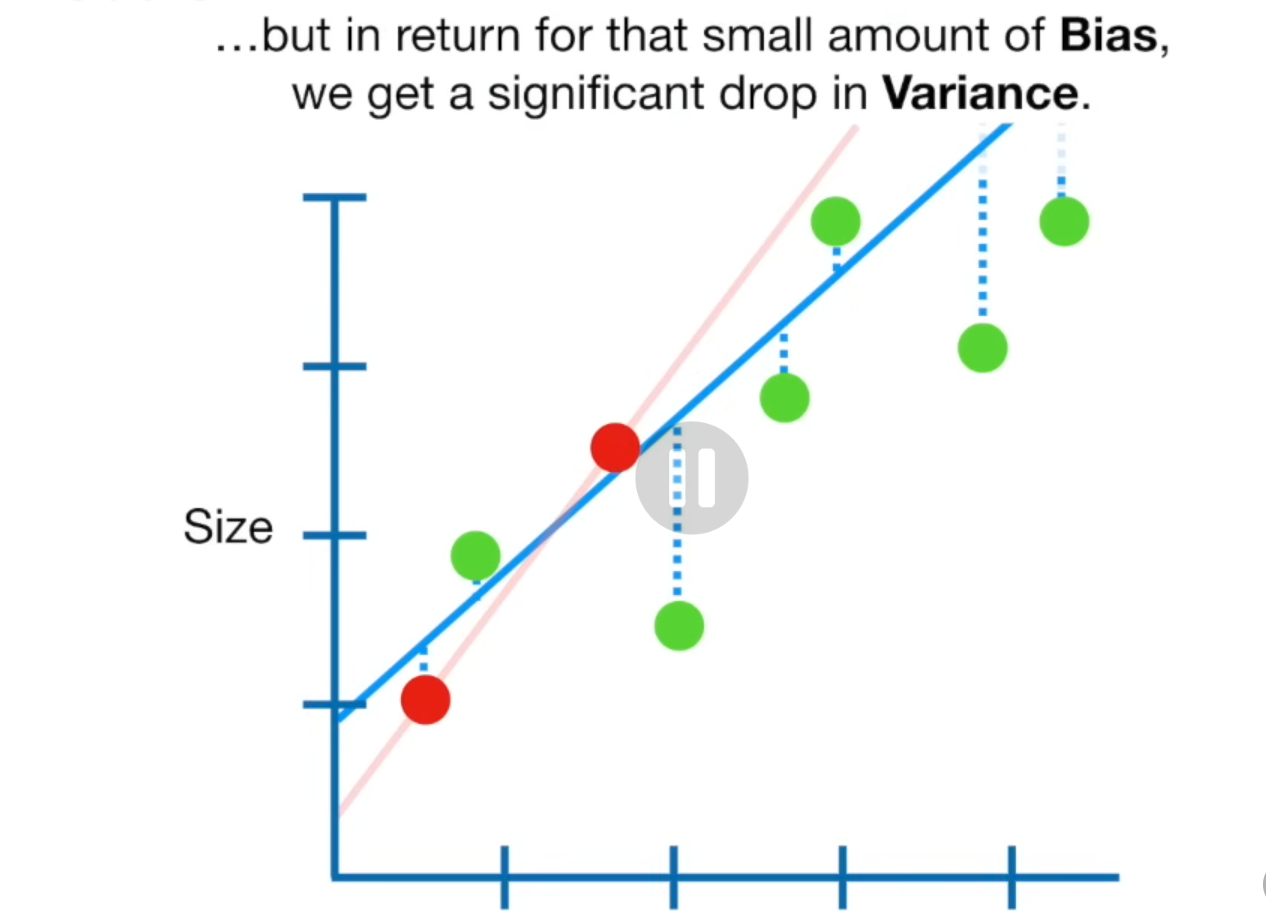

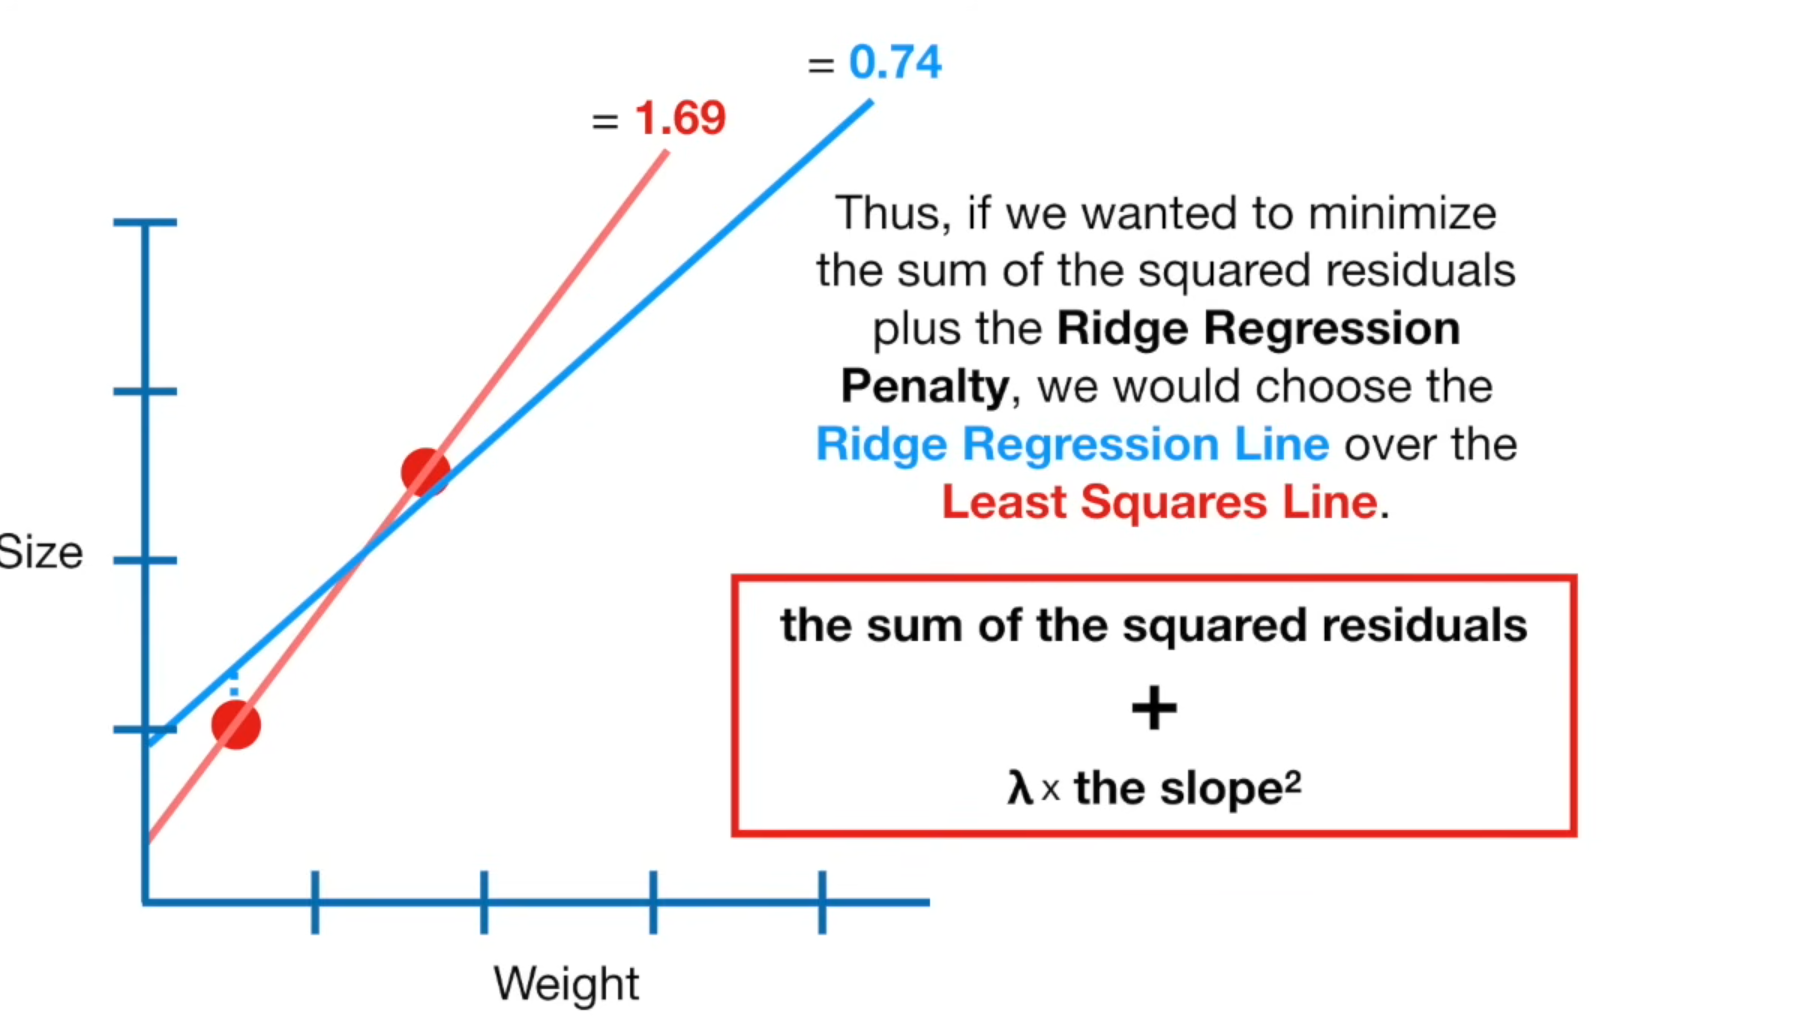

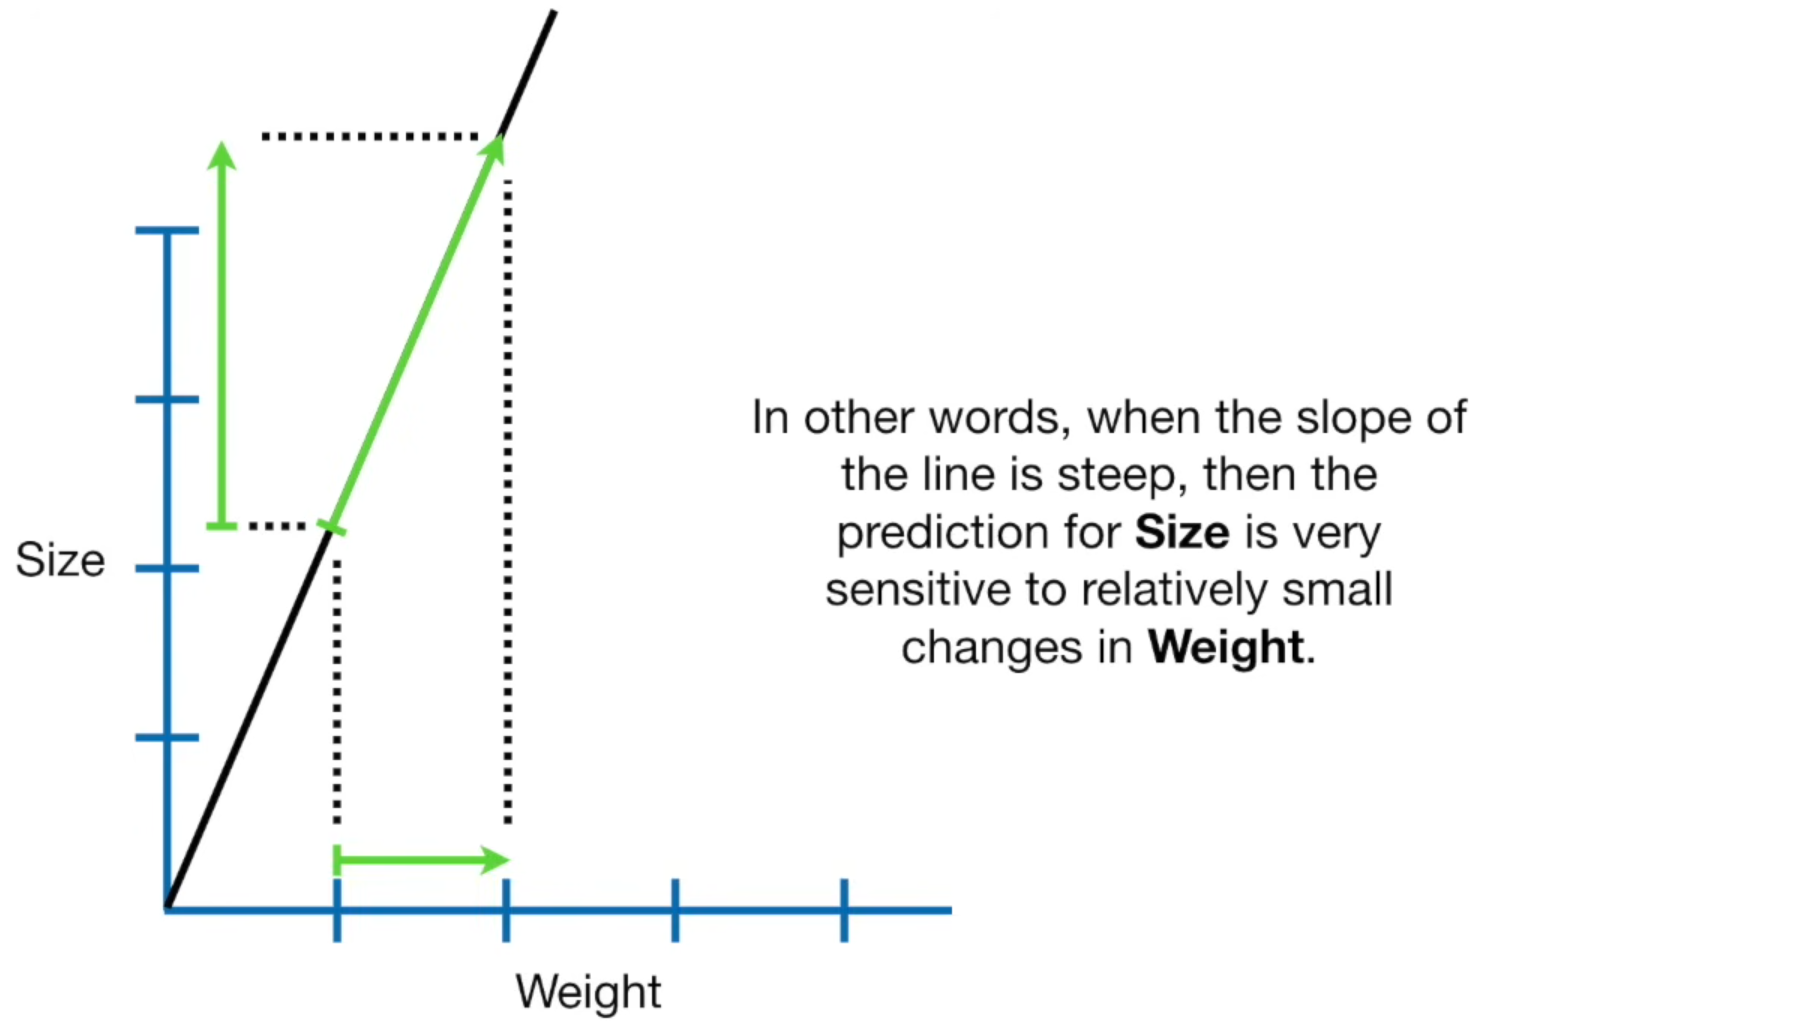


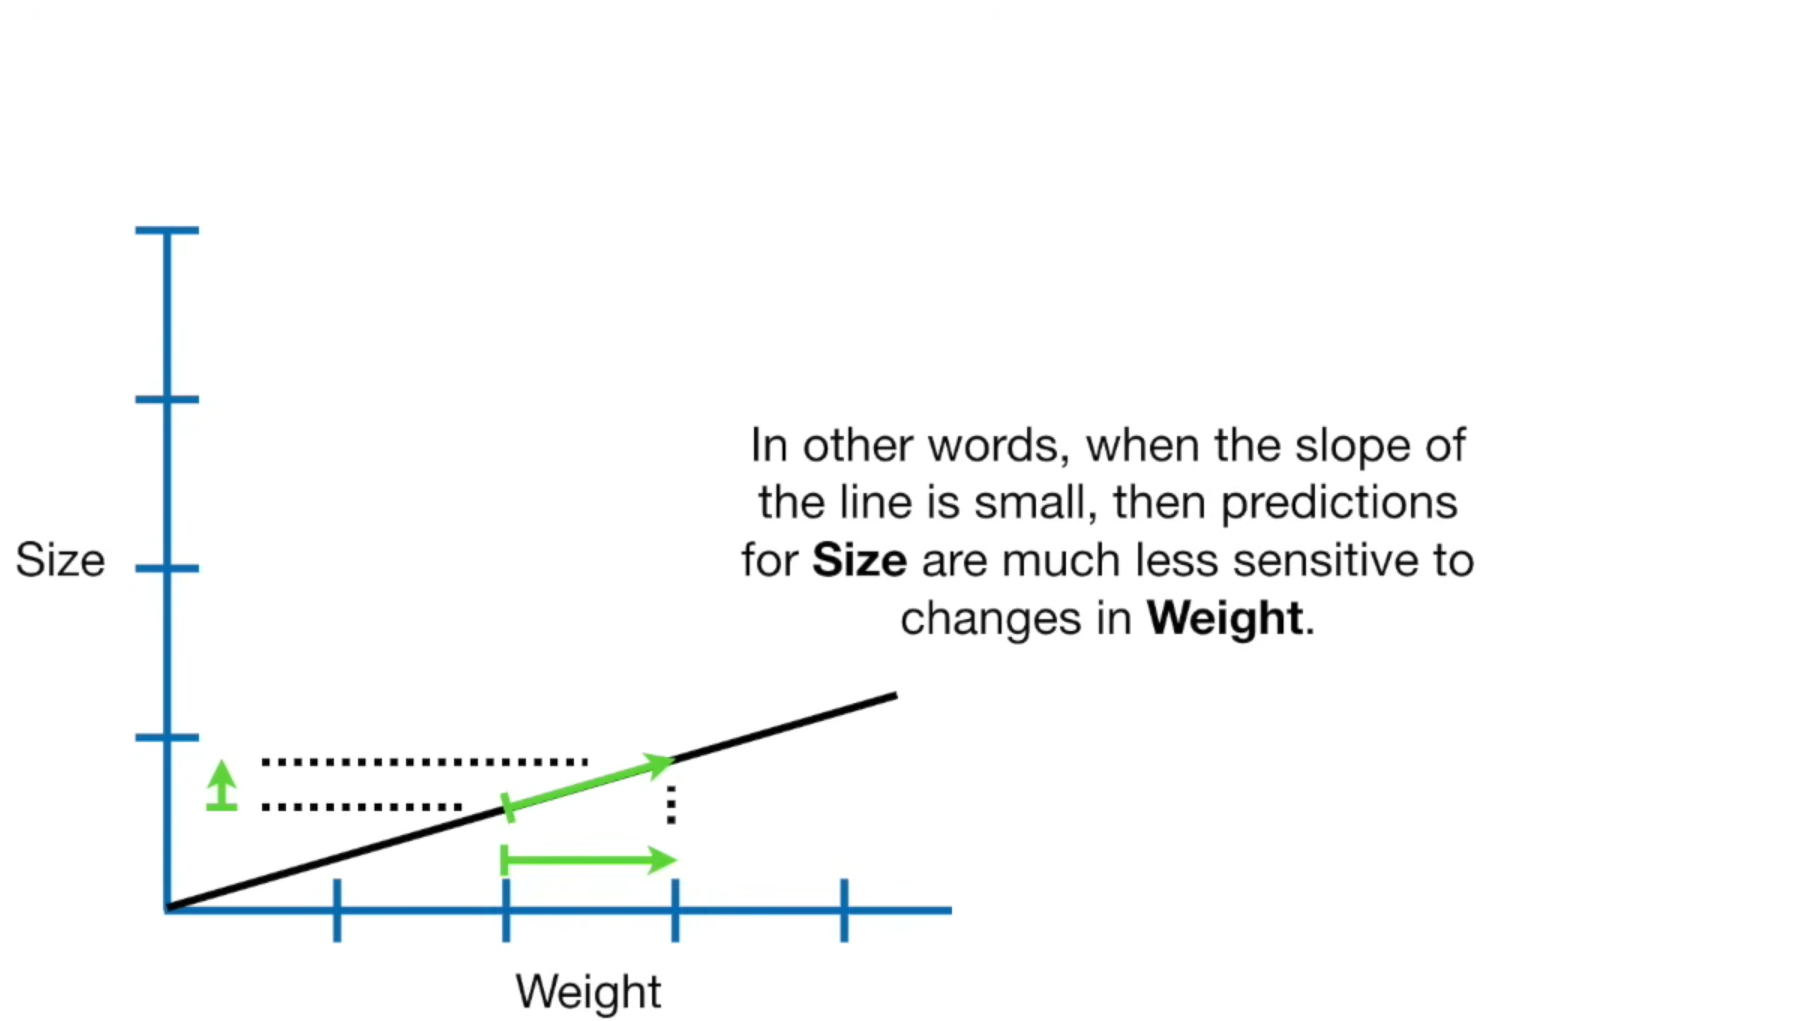

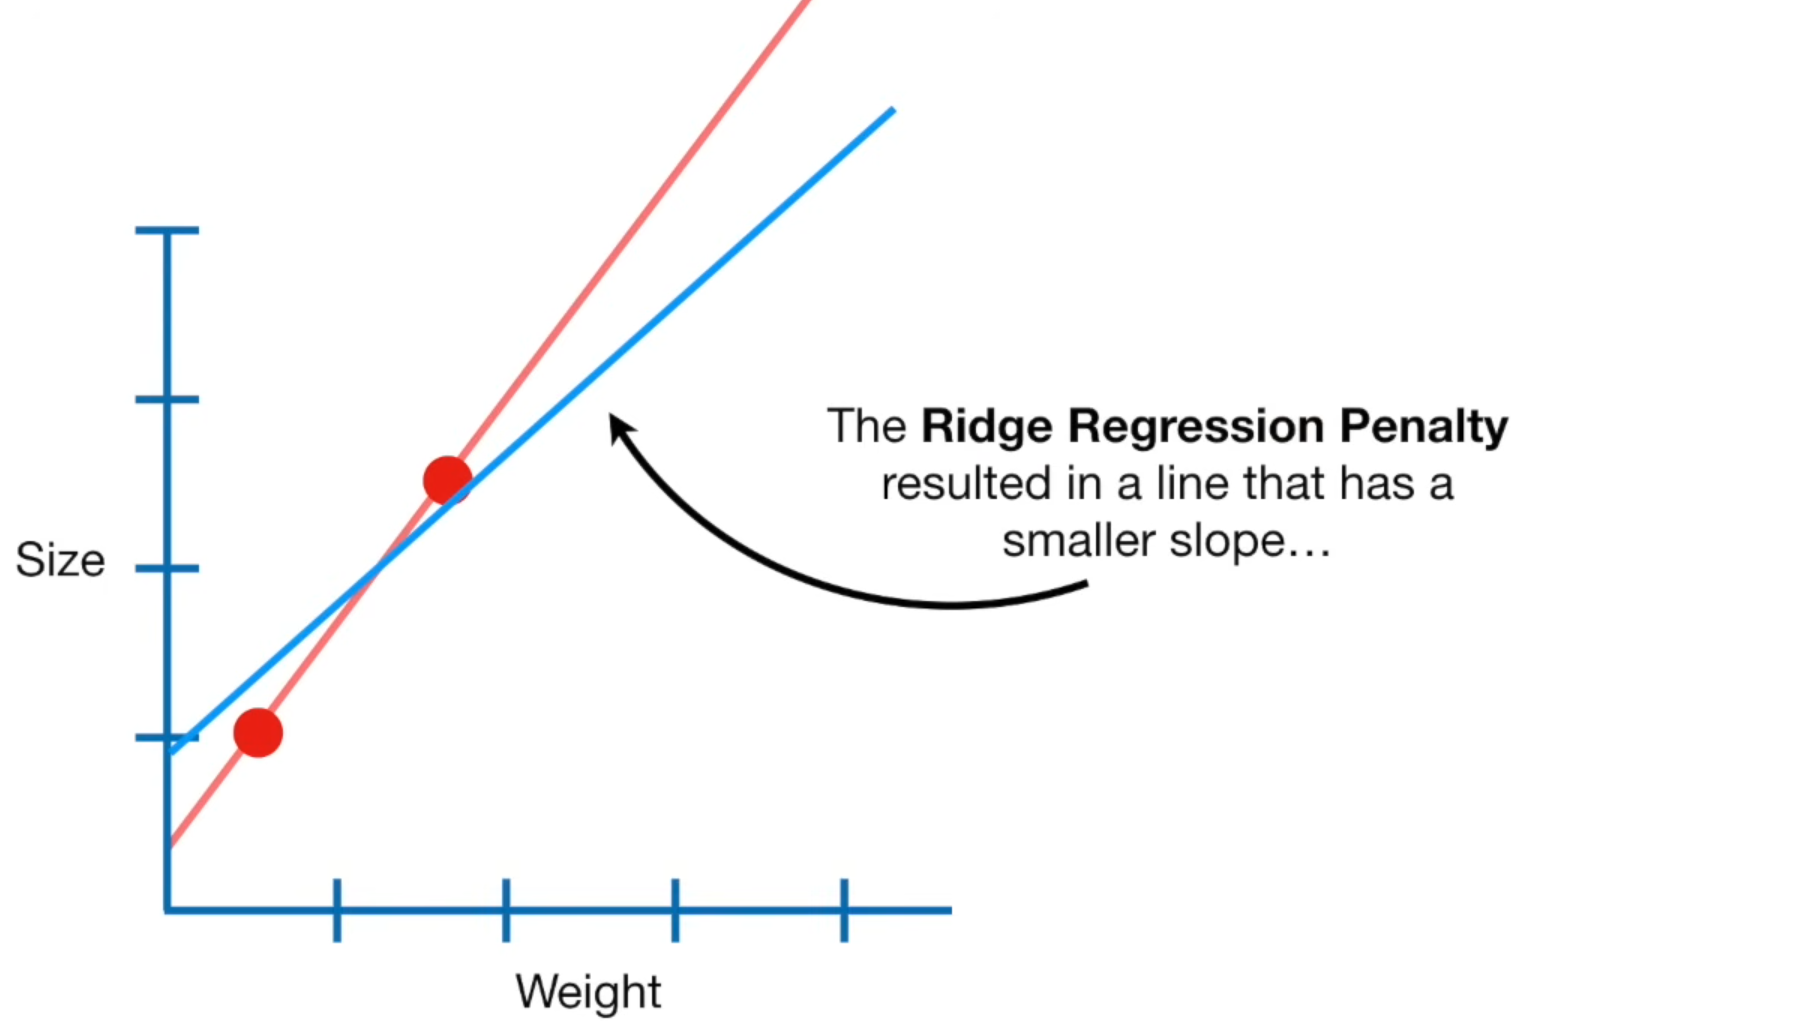

# Ridge Regularization — Lecture Notes
> *Geometric Intuition and Code | Regularized Linear Models*

---

## What's on the Board

### The Big Picture — 3 Types of Regularization
1. **Ridge (L2)**
2. **Lasso (L1)**
3. **Elastic Net**

---

## 1. The Overfitting Problem (Right Side of Board)

The instructor draws two extreme lines through the data:
Model: `y = mx + b`

- When slope `m → ∞`, the line chases every data point → **overfits**
- We want a slope somewhere in between
- Ridge **penalizes large slopes** to prevent this

---

## 2. The Core Idea — Two Competing Lines

On the left graph, two fitted lines are shown through the same data:

| Line | Equation | Label | Loss |
|------|----------|-------|------|
| Normal OLS | `y = 1.5x + 0.8` | L_N | Lower training loss |
| Ridge | `y = 0.9x + 1.5` | L_R | Higher training loss, but penalizes slope |

> Ridge **sacrifices some training accuracy** to keep the slope (coefficient) small.

---

## 3. Ridge Loss Function

$$
\boxed{
L_{\text{Ridge}} = \sum_{i=1}^{n}(y_i - \hat{y}_i)^2 + \lambda(m^2)
}
$$

| Term | Meaning |
|------|---------|
| $\sum(y_i - \hat{y}_i)^2$ | Standard MSE loss |
| $\lambda$ | Regularization strength (hyperparameter — marked **hp** on board) |
| $m^2$ | Penalty on the slope (L2 = squared) |
| $[0 - \alpha]$ | The range for intercept `b` (b = slope is in range 0 to α) |

> The penalty term `λ(m²)` is what makes it **Ridge / L2** — it squares the coefficient.

---








## 3.1 Loss function calculation
$$
L = \sum_{i=1}^n(y_i- mx_i-b)^2\\
\frac{\delta(L)}{\delta(b)} = \sum2(y_i-mx_i-b)(-1)\\
0 = -(\sum(y_i)+m*\sum(x_i)-\sum(b))\\
L = \sum_{i=1}^n(y_i- mx_i-\bar{y}-m\bar{x})^2+ \lambda*m^2\\
\frac{\delta(L)}{\delta(m)}=2\sum_{i=1}^n(y_i- mx_i-\bar{y}+m\bar{x})(-x_i+\bar{x})+2\lambda m\\
\lambda m - \sum_{i=1}^{n}[(y_i-\bar{y})-m(x_i-\bar{x})](x_i-\bar{x})=0\\
m = \frac{\sum_{i=1}^{n}(y_i-\hat{y})(x_i-\hat{x})}{\sum_{i=1}^{n}(x_i-\bar{y})^2+\lambda}\\
\text{as the value of }\lambda \text{will increase the m will decrease}
$$

## 4. Numerical Example (The Table)

Two data points used: **(1, 2.3)** and **(3, 5.3)**

### Normal Loss L_N
Fitted line: `y = 1.5x + 0.8`

$$
L_N = (2.3 - 1.5 - 0.8)^2 + (5.3 - 4.5 - 0.8)^2 = (0)^2 + (0)^2 \approx 0
$$

*(Line passes almost perfectly through both points)*

---

### Ridge Loss L_R  with λ = 1
Fitted line: `y = 0.9x + 1.5`

$$
L_R = (2.3 - 0.9 - 1.5)^2 + (5.3 - 2.7 - 1.5)^2 + (0.9)^2
$$

$$
= (0.1)^2 + (1.1)^2 + (0.9)^2
$$

$$
= 0.01 + 1.21 + 0.81
$$

$$
\boxed{= 2.03}
$$

> Even though `L_R = 2.03 > L_N`, the Ridge model is preferred because the **slope 0.9 < 1.5** — it generalizes better.

---

## 5. Key Takeaway
Normal loss only cares about:     how well line fits training data

Ridge loss also cares about:      how LARGE the slope is
→ Ridge trades a little training accuracy

for a much smaller, safer coefficient

→ This reduces overfitting on test data
### The λ Tradeoff

| λ | Effect |
|---|--------|
| λ = 0 | Pure OLS — no regularization |
| λ small | Slight shrinkage of slope |
| λ large | Slope heavily shrunk toward 0 |
| λ → ∞ | Slope = 0, flat line (underfitting) |

---

## 6. Why Squared (L2) and not Absolute (L1)?

| | Ridge (L2) | Lasso (L1) |
|--|------------|------------|
| Penalty | $m^2$ | $\|m\|$ |
| Differentiable? | ✅ Yes — smooth gradient | ❌ No — kink at 0 |
| Zeroes out coefficients? | ❌ Never exactly | ✅ Yes |
| Closed-form solution? | ✅ Yes | ❌ No |

Ridge uses $m^2$ → always differentiable → clean gradient descent update.

---

In [2]:
import numpy as np
import pandas as pd
from sklearn .datasets import load_diabetes
X,y = load_diabetes(return_X_y=True)


In [3]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train ,y_test = train_test_split(X,y,test_size=0.3)

In [4]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train,y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [12]:
print(lr.coef_)

[ -29.60504003 -183.86274148  621.48471314  256.21553155 -598.71495355
  380.79802177   56.41415259  111.00779069  640.63832268   69.0352824 ]


In [ ]:

print(lr.intercept_)

[ -29.60504003 -183.86274148  621.48471314  256.21553155 -598.71495355
  380.79802177   56.41415259  111.00779069  640.63832268   69.0352824 ]
153.38824096835648


In [6]:
out = lr.predict(X_test)

In [7]:
from sklearn.metrics import r2_score
res = r2_score(y_test,out)
print(res)

0.5008096233170765


### implimentation

### Using Ridge Regression

In [8]:
from sklearn.linear_model import Ridge
R = Ridge(alpha=0.089)

In [9]:
R.fit(X_train,y_train)


,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",0.089
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None

In [10]:
y1_pred = R.predict(X_test)
print(r2_score(y_test,y1_pred))

0.494344880939651


In [11]:
print()